# Box 4 POC — Mean-Variance Capital Allocation: Model A vs Model B (SPY, 10y)

**Question this notebook answers:** *given the two strategies the platform already
backtests — Model A (Logistic Regression) and Model B (SMA Crossover) — what % of
capital should the book allocate to each, and **why**?*

This is the constructive half of **Box 4 (`risk_management/`)**. Today Box 4 only has a
defensive drawdown **veto** (`portfolio/guardrail.py`). Here we prototype the
**Model Portfolio Capital Allocation Engine** from
`risk_management/PORTFOLIO_ALLOCATION_REQUIREMENTS.md`, focusing on **mean-variance
(Markowitz)** and benchmarking it against Kelly, risk-parity, and equal-weight.

### Where mean-variance fits
Mean-variance is the method that **prices diversification**. Kelly maximizes log-growth
from each edge in isolation; risk-parity equalizes risk; equal-weight ignores everything.
Only mean-variance uses the **covariance between strategies** — so it is the method that
tells you whether a second strategy actually *adds* something or is just a redundant copy
of the first. That makes it the right lens for "how much of strategy X belongs in the book."

$$\max_w \; \frac{w^\top \mu}{\sqrt{w^\top \Sigma w}} \quad\text{s.t.}\quad \sum_i w_i = 1,\; w_i \ge 0$$

where $\mu$ = annualized expected returns and $\Sigma$ = annualized covariance of the two
strategies' **daily return series**. The max-Sharpe (tangency) solution is $w \propto \Sigma^{-1}\mu$.

## Box 1 → 3 — reproduce the engine
We reproduce Model A / Model B faithfully from `interface/streamlit/app.py` (deployed LR
weights; SMA crossover; all-in/all-out long backtest on 10y SPY) so the allocation runs on
the **same return series the dashboard shows**.

In [1]:
import sys, os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

sys.path.append(os.path.abspath("../../"))  # repo root (convention from other notebooks)
plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.25})

INIT = 100_000.0
START, END = "2016-05-27", "2026-05-12"
FAST, SLOW, RSI_P, THRESH = 50, 200, 14, 0.50

df = pd.read_csv("../../assets/SPY_10y.csv")
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df = df.set_index("Date").sort_index()


def compute_rsi(series, period=14):
    delta = series.diff()
    ag = delta.clip(lower=0).ewm(com=period - 1, adjust=False).mean()
    al = (-delta.clip(upper=0)).ewm(com=period - 1, adjust=False).mean()
    return 100 - (100 / (1 + ag / al))


df["Fast_SMA"] = df["Close"].rolling(FAST).mean()
df["Slow_SMA"] = df["Close"].rolling(SLOW).mean()
df["RSI"] = compute_rsi(df["Close"], RSI_P)
df["Prev_Close"] = df["Close"].shift(1)
sim = df.loc[START:END].copy()
print(f"Loaded {len(sim)} trading days: {sim.index[0].date()} -> {sim.index[-1].date()}")

Loaded 2502 trading days: 2016-05-31 -> 2026-05-12


In [2]:
# --- Model A: deployed logistic-regression probability crossover ---
dW = {"sma_ratio": 2.5, "rsi_norm": 0.5, "momentum": 1.0}
dI = 0.1
dM = {"sma_ratio": 0.005, "rsi_norm": 0.02, "momentum": 0.0003}
dS = {"sma_ratio": 0.03, "rsi_norm": 0.35, "momentum": 0.015}

sig_a, prev = [], None
for _, r in sim.iterrows():
    fs, ss, rsi, pc, c = r.Fast_SMA, r.Slow_SMA, r.RSI, r.Prev_Close, r.Close
    if pd.isna(fs) or pd.isna(ss) or pd.isna(rsi) or pd.isna(pc):
        sig_a.append("NONE")
        continue
    z = (
        dI
        + dW["sma_ratio"] * ((fs / ss - 1) - dM["sma_ratio"]) / dS["sma_ratio"]
        + dW["rsi_norm"] * (((rsi - 50) / 50) - dM["rsi_norm"]) / dS["rsi_norm"]
        + dW["momentum"] * ((c / pc - 1) - dM["momentum"]) / dS["momentum"]
    )
    prob = 1 / (1 + math.exp(-z)) if z >= 0 else math.exp(z) / (1 + math.exp(z))
    sig_a.append(
        "GOLDEN_CROSS"
        if (prev is not None and prev <= THRESH < prob)
        else "DEATH_CROSS"
        if (prev is not None and prev > THRESH >= prob)
        else "NONE"
    )
    prev = prob
sim["A_sig"] = sig_a

# --- Model B: SMA 50/200 crossover ---
sig_b, pf, ps = [], None, None
for _, r in sim.iterrows():
    fs, ss = r.Fast_SMA, r.Slow_SMA
    sig_b.append(
        "GOLDEN_CROSS"
        if (pf is not None and pf <= ps and fs > ss)
        else "DEATH_CROSS"
        if (pf is not None and pf >= ps and fs < ss)
        else "NONE"
    )
    pf, ps = fs, ss
sim["B_sig"] = sig_b


# --- Box 3: all-in / all-out long backtest ---
def backtest(col):
    vals, cash, shares, pos = [], INIT, 0.0, 0
    for _, r in sim.iterrows():
        c, s = r.Close, r[col]
        if s == "GOLDEN_CROSS" and pos == 0:
            shares, cash, pos = cash / c, 0.0, 1
        elif s == "DEATH_CROSS" and pos == 1:
            cash, shares, pos = shares * c, 0.0, 0
        vals.append(cash + shares * c)
    return pd.Series(vals, index=sim.index)


equity = pd.DataFrame(
    {
        "Model A (LR)": backtest("A_sig"),
        "Model B (SMA)": backtest("B_sig"),
        "Benchmark (SPY B&H)": (INIT / sim.Close.iloc[0]) * sim.Close,
    }
)
equity.tail(3)

,Model A (LR),Model B (SMA),Benchmark (SPY B&H)
Date,,,
2026-05-08 04:00:00+00:00,168934.590300,212815.273780,413747.420854
2026-05-11 04:00:00+00:00,169319.353289,213299.978782,414689.766020
2026-05-12 04:00:00+00:00,169062.844630,212976.842114,414061.535910


## Per-strategy stats & the key number: correlation
The allocator's whole job hinges on **how correlated the two strategies are**. If they move
together, there is nothing to diversify and the math will (correctly) refuse to split capital.

In [3]:
def stats(s):
    rets = s.pct_change().dropna()
    yrs = len(s) / 252
    return dict(
        Total=f"{(s.iloc[-1]/s.iloc[0]-1)*100:.1f}%",
        CAGR=f"{((s.iloc[-1]/s.iloc[0])**(1/yrs)-1)*100:.1f}%",
        Vol=f"{rets.std()*np.sqrt(252)*100:.1f}%",
        Sharpe=f"{np.sqrt(252)*rets.mean()/rets.std():.2f}",
        MaxDD=f"{((s-s.cummax())/s.cummax()).min()*100:.1f}%",
    )


stats_tbl = pd.DataFrame({c: stats(equity[c]) for c in equity}).T
R = equity[["Model A (LR)", "Model B (SMA)"]].pct_change().dropna()
corr = R.corr().iloc[0, 1]
print(f"Correlation(A, B) of daily returns = {corr:.3f}")
print(
    f"Time in cash:  A = {(R['Model A (LR)']==0).mean()*100:.0f}%   B = {(R['Model B (SMA)']==0).mean()*100:.0f}%"
)
stats_tbl

Correlation(A, B) of daily returns = 0.879
Time in cash:  A = 42%   B = 42%


,Total,CAGR,Vol,Sharpe,MaxDD
Model A (LR),69.1%,5.4%,12.7%,0.48,-43.6%
Model B (SMA),113.0%,7.9%,14.0%,0.61,-33.7%
Benchmark (SPY B&H),314.1%,15.4%,18.0%,0.89,-33.7%


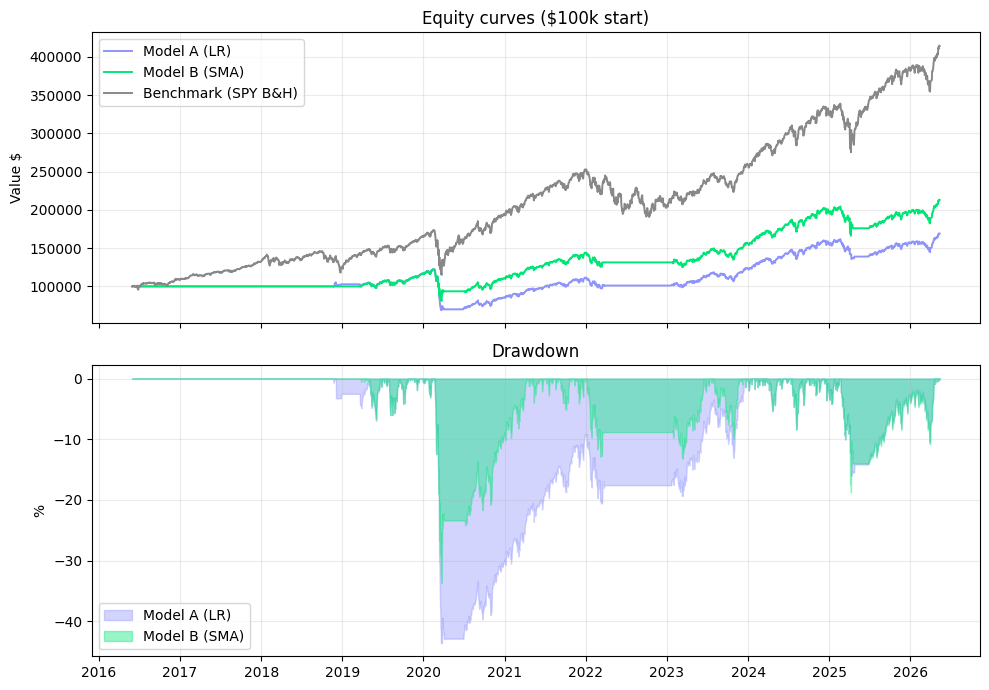

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for c, color in zip(equity, ["#8F94FB", "#00E676", "#888"]):
    ax[0].plot(equity.index, equity[c], label=c, color=color, lw=1.4)
ax[0].set_title("Equity curves ($100k start)")
ax[0].legend()
ax[0].set_ylabel("Value $")
for c, color in zip(["Model A (LR)", "Model B (SMA)"], ["#8F94FB", "#00E676"]):
    dd = (equity[c] - equity[c].cummax()) / equity[c].cummax()
    ax[1].fill_between(dd.index, dd * 100, 0, color=color, alpha=0.4, label=c)
ax[1].set_title("Drawdown")
ax[1].set_ylabel("%")
ax[1].legend()
plt.tight_layout()
plt.show()

## Box 4 — the allocation engine
We annualize $\mu$ and $\Sigma$ from the daily return series, then solve four philosophies:

| Method | What it optimizes | Uses $\Sigma$? |
|---|---|---|
| **Max-Sharpe (mean-variance)** | best risk-adjusted return | ✅ full covariance |
| **Min-Variance** | lowest portfolio vol | ✅ |
| **Risk Parity** | equal risk contribution | ✅ (diagonal-ish) |
| **Kelly** | long-run log-growth | ✅ ($\Sigma^{-1}\mu$) |
| **Equal-Weight 1/N** | nothing (humility baseline) | ❌ |

In [5]:
mu = R.mean().values * 252
Sigma = R.cov().values * 252


def port(w):
    w = np.asarray(w)
    v = math.sqrt(w @ Sigma @ w)
    return w @ mu, v, (w @ mu) / v if v > 0 else 0


cons = ({"type": "eq", "fun": lambda w: w.sum() - 1},)
bnds = ((0, 1), (0, 1))
w0 = np.array([0.5, 0.5])
w_tan = minimize(lambda w: -port(w)[2], w0, bounds=bnds, constraints=cons).x
w_mv = minimize(lambda w: w @ Sigma @ w, w0, bounds=bnds, constraints=cons).x


def rp(w):
    w = np.asarray(w)
    s = math.sqrt(w @ Sigma @ w)
    rc = w * ((Sigma @ w) / s)
    return ((rc - rc.mean()) ** 2).sum()


w_rp = minimize(rp, w0, bounds=bnds, constraints=cons).x
w_eq = np.array([0.5, 0.5])
f_star = np.linalg.solve(Sigma, mu)  # continuous Kelly (direction)
w_kelly = np.clip(f_star, 0, None)
w_kelly = w_kelly / w_kelly.sum()  # long-only normalized

rows = []
for name, w in [
    ("Max-Sharpe (MV)", w_tan),
    ("Min-Variance", w_mv),
    ("Risk Parity", w_rp),
    ("Kelly (long-only)", w_kelly),
    ("Equal-Weight", w_eq),
]:
    ret, vol, sh = port(w)
    rows.append(
        [
            name,
            f"{w[0]*100:.0f}%",
            f"{w[1]*100:.0f}%",
            f"{ret*100:.1f}%",
            f"{vol*100:.1f}%",
            f"{sh:.3f}",
        ]
    )
alloc = pd.DataFrame(
    rows, columns=["Method", "Model A", "Model B", "Exp.Return", "Exp.Vol", "Sharpe"]
)
gross = f_star.sum()
print(
    f"Full-Kelly gross exposure = {gross:.2f}x  ->  half-Kelly = {gross/2:.2f}x  (must be leverage-capped)"
)
alloc

Full-Kelly gross exposure = 3.96x  ->  half-Kelly = 1.98x  (must be leverage-capped)


,Method,Model A,Model B,Exp.Return,Exp.Vol,Sharpe
0,Max-Sharpe (MV),0%,100%,8.6%,14.0%,0.613
1,Min-Variance,91%,9%,6.3%,12.7%,0.501
2,Risk Parity,52%,48%,7.3%,12.9%,0.565
3,Kelly (long-only),0%,100%,8.6%,14.0%,0.613
4,Equal-Weight,50%,50%,7.4%,12.9%,0.568


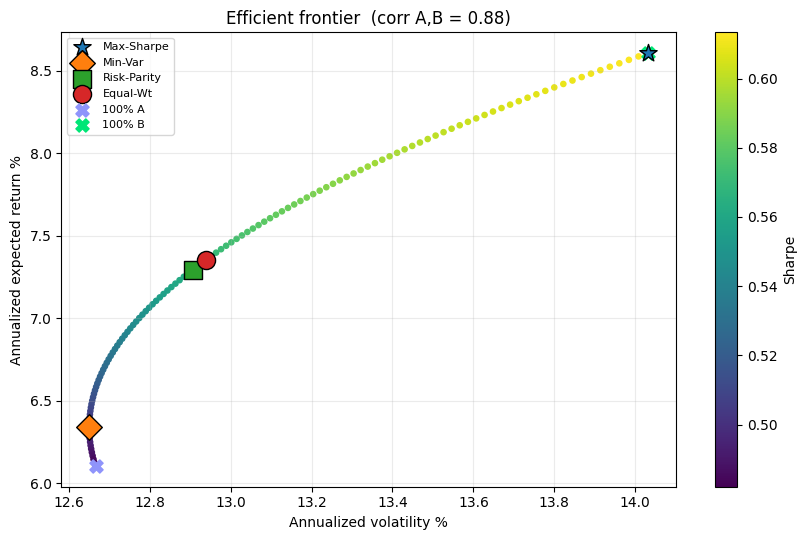

In [6]:
# Efficient frontier (2 long-only assets => the frontier is the sweep wA in [0,1])
ws = np.linspace(0, 1, 121)
pts = np.array([port([wa, 1 - wa])[:2] for wa in ws])  # (ret, vol)
shs = np.array([port([wa, 1 - wa])[2] for wa in ws])

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sc = ax.scatter(pts[:, 1] * 100, pts[:, 0] * 100, c=shs, cmap="viridis", s=14)
plt.colorbar(sc, label="Sharpe")
for w, lbl, mk in [
    (w_tan, "Max-Sharpe", "*"),
    (w_mv, "Min-Var", "D"),
    (w_rp, "Risk-Parity", "s"),
    (w_eq, "Equal-Wt", "o"),
]:
    ret, vol, _ = port(w)
    ax.scatter(vol * 100, ret * 100, marker=mk, s=170, edgecolor="k", zorder=5, label=lbl)
ax.scatter(
    port([1, 0])[1] * 100, port([1, 0])[0] * 100, c="#8F94FB", s=90, marker="X", label="100% A"
)
ax.scatter(
    port([0, 1])[1] * 100, port([0, 1])[0] * 100, c="#00E676", s=90, marker="X", label="100% B"
)
ax.set_xlabel("Annualized volatility %")
ax.set_ylabel("Annualized expected return %")
ax.set_title(f"Efficient frontier  (corr A,B = {corr:.2f})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

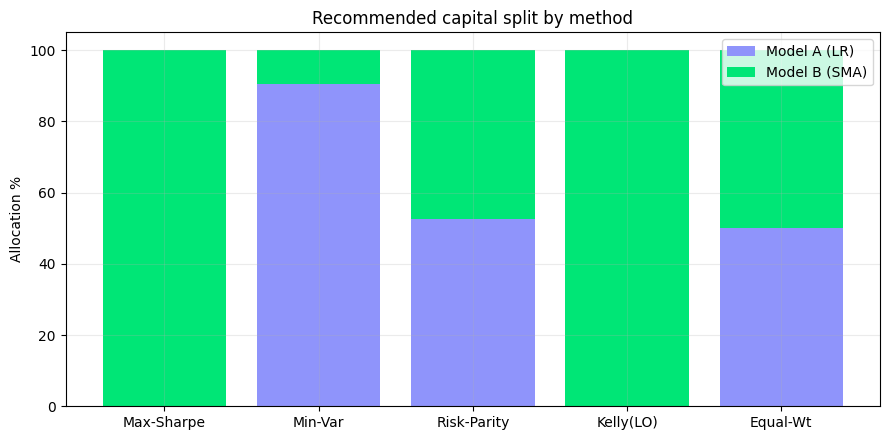

In [7]:
# Allocation by method
fig, ax = plt.subplots(figsize=(9, 4.5))
A = [w_tan[0], w_mv[0], w_rp[0], w_kelly[0], w_eq[0]]
B = [w_tan[1], w_mv[1], w_rp[1], w_kelly[1], w_eq[1]]
labels = ["Max-Sharpe", "Min-Var", "Risk-Parity", "Kelly(LO)", "Equal-Wt"]
ax.bar(labels, np.array(A) * 100, label="Model A (LR)", color="#8F94FB")
ax.bar(labels, np.array(B) * 100, bottom=np.array(A) * 100, label="Model B (SMA)", color="#00E676")
ax.set_ylabel("Allocation %")
ax.set_title("Recommended capital split by method")
ax.legend()
plt.tight_layout()
plt.show()

## The *why* — grounded explanation (Tier-1 attribution)
The requirements doc asks the engine to explain its weights, citing numbers (cite-or-abstain,
reusing `governance/grounding.py`). Here is that explanation generated from the figures above.

In [8]:
shA = float(stats_tbl.loc["Model A (LR)", "Sharpe"])
shB = float(stats_tbl.loc["Model B (SMA)", "Sharpe"])
better = "Model B (SMA)" if shB >= shA else "Model A (LR)"
worse = "Model A (LR)" if better.startswith("Model B") else "Model B (SMA)"

why = f"""
WHY THESE WEIGHTS  (all numbers traced to the cells above)
-----------------------------------------------------------
- Edge:       {better} has the higher risk-adjusted edge (Sharpe {max(shA,shB):.2f} vs {min(shA,shB):.2f}).
- Redundancy: the two strategies are {corr:.2f} correlated -- both are long-only SPY
              timing overlays, in cash ~42% of the time, often the SAME days.
- Mean-Variance => {alloc.iloc[0]["Model A"]} A / {alloc.iloc[0]["Model B"]} B.
              With corr {corr:.2f} there is almost NO diversification to harvest, so the
              max-Sharpe solution concentrates in {better} and the blended Sharpe
              ({port(w_tan)[2]:.3f}) barely beats holding {better} alone ({max(shA,shB):.3f}).
              => MV is being HONEST: a near-duplicate strategy earns ~0% of the book.
- Min-Variance => {alloc.iloc[1]["Model A"]} A / {alloc.iloc[1]["Model B"]} B, tilting to the
              lower-vol leg to shave portfolio volatility.
- Risk-Parity / Equal-Weight => ~50/50: the "humble" split you use when you do NOT trust
              the expected-return estimates (usually the right prior in practice).
- Kelly wants {gross:.1f}x gross leverage (half-Kelly {gross/2:.1f}x) and would even short
              {worse}; this MUST be clamped by the Box-4 constraints (long-only,
              gross-leverage cap, per-strategy cap).

CONSTRAINTS THAT BOUND THE RAW MATH (=> §4 of PORTFOLIO_ALLOCATION_REQUIREMENTS.md):
  long-only, max gross leverage 1.0x, per-strategy cap, correlation penalty, halt-aware.
"""
print(why)


WHY THESE WEIGHTS  (all numbers traced to the cells above)
-----------------------------------------------------------
- Edge:       Model B (SMA) has the higher risk-adjusted edge (Sharpe 0.61 vs 0.48).
- Redundancy: the two strategies are 0.88 correlated -- both are long-only SPY
              timing overlays, in cash ~42% of the time, often the SAME days.
- Mean-Variance => 0% A / 100% B.
              With corr 0.88 there is almost NO diversification to harvest, so the
              max-Sharpe solution concentrates in Model B (SMA) and the blended Sharpe
              (0.613) barely beats holding Model B (SMA) alone (0.610).
              => MV is being HONEST: a near-duplicate strategy earns ~0% of the book.
- Min-Variance => 91% A / 9% B, tilting to the
              lower-vol leg to shave portfolio volatility.
- Risk-Parity / Equal-Weight => ~50/50: the "humble" split you use when you do NOT trust
              the expected-return estimates (usually the right prior in practice)

## What this POC proves for Box 4

1. **Mean-variance is the diversification referee.** With only two strategies that are 0.88
   correlated, MV correctly refuses to diversify and routes ~all capital to the higher-Sharpe
   model — the blended Sharpe gain over the best single strategy is ≈ 0. *This is the feature,
   not a bug:* it stops the book from paying for a redundant strategy.

2. **The portfolio is starved of uncorrelated edges.** The single highest-impact follow-up is
   **Box 2 breadth** — add strategies with low/negative correlation to these two (a mean-reversion
   model, a different asset, a regime/HMM overlay à la Acadia). MV only creates value when fed
   *uncorrelated* bets — the Medallion principle.

3. **The risk constraints in the requirements doc are necessary, not decorative.** Raw Kelly here
   asks for ~4x leverage and a short; without the long-only / leverage-cap / per-strategy-cap /
   correlation-penalty guardrails (§4), the "optimal" answer is un-investable.

4. **Method choice = risk philosophy.** Same data, five defensible answers (0%→100% on Model A).
   The Box-4 dashboard should let the user pick the method and **show the *why***, exactly as
   prototyped here.

**Next:** promote this into `risk_management/portfolio/sizing.py` + `enterprise/allocator.py`
(Phase 1–2 of the requirements doc), then wire the panel into Box 4 of the Streamlit app.